In [ ]:
LAB1 DE REGRESIÓN LINEA

In [1]:
# utilizado para manejos de directorios y rutas
import os
# Computacion vectorial y cientifica para python
import numpy as np
# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D
# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

hacer la importacionde del datset


In [4]:
import pandas as pd
data = pd.read_csv('/content/diamonds.csv')
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
X = data.drop("price", axis=1)
y = data["price"]
m = y.size
print("Número de ejemplos:", m)

Número de ejemplos: 53940


In [6]:
X = pd.get_dummies(X)

In [7]:
print("Dimensiones de X:", X.shape)

Dimensiones de X: (53940, 26)


In [8]:
print(data)

       carat        cut color clarity  depth  table  price     x     y     z
0       0.23      Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1       0.21    Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2       0.23       Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3       0.29    Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4       0.31       Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
...      ...        ...   ...     ...    ...    ...    ...   ...   ...   ...
53935   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64

[53940 rows x 10 columns]


In [9]:
print(X)

       carat  depth  table     x     y     z  cut_Fair  cut_Good  cut_Ideal  \
0       0.23   61.5   55.0  3.95  3.98  2.43     False     False       True   
1       0.21   59.8   61.0  3.89  3.84  2.31     False     False      False   
2       0.23   56.9   65.0  4.05  4.07  2.31     False      True      False   
3       0.29   62.4   58.0  4.20  4.23  2.63     False     False      False   
4       0.31   63.3   58.0  4.34  4.35  2.75     False      True      False   
...      ...    ...    ...   ...   ...   ...       ...       ...        ...   
53935   0.72   60.8   57.0  5.75  5.76  3.50     False     False       True   
53936   0.72   63.1   55.0  5.69  5.75  3.61     False      True      False   
53937   0.70   62.8   60.0  5.66  5.68  3.56     False     False      False   
53938   0.86   61.0   58.0  6.15  6.12  3.74     False     False      False   
53939   0.75   62.2   55.0  5.83  5.87  3.64     False     False       True   

       cut_Premium  ...  color_I  color_J  clarity_

In [10]:
print(y)

0         326
1         326
2         327
3         334
4         335
         ... 
53935    2757
53936    2757
53937    2757
53938    2757
53939    2757
Name: price, Length: 53940, dtype: int64


In [11]:
print(X.size)

1402440


In [12]:
def plotData(x, y):
    fig = pyplot.figure()
    pyplot.scatter(x, y)
    pyplot.ylabel("Precio del diamante")
    pyplot.xlabel("Peso del diamante (carat)")

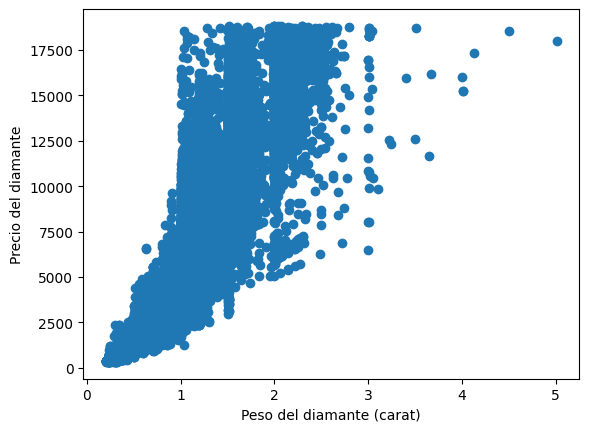

In [14]:
plotData(data["carat"], data["price"])

Primero debes convertir X a matriz numpy y luego agregar la columna de unos.

In [15]:
X = X.values

Después agregas la columna de unos:

In [16]:
X = np.concatenate([np.ones((m,1)), X], axis=1)

In [18]:
# agregar columna de unos (intercepto)
X = np.concatenate([np.ones((m,1)), X], axis=1)

print(X.shape)

(53940, 28)


In [19]:
print(X)

[[1.0 1.0 0.23 ... False False False]
 [1.0 1.0 0.21 ... False False False]
 [1.0 1.0 0.23 ... False False False]
 ...
 [1.0 1.0 0.7 ... False False False]
 [1.0 1.0 0.86 ... False False False]
 [1.0 1.0 0.75 ... False False False]]


Cálculo del costo  J(θ)

In [20]:
def calcularCosto(X, y, theta):
    m = y.size  # numero de ejemplos de entrenamiento
    J = 0
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

Ejemplo de funcionamiento de la funcion computeCoste con dos valores diferentes de  θ .

In [21]:
theta = np.zeros(X.shape[1])

In [22]:
theta = np.zeros(X.shape[1])

J = calcularCosto(X, y, theta)
print('Con theta inicial = 0 \nCosto calculado = %.2f' % J)

Con theta inicial = 0 
Costo calculado = 15691124.01


In [23]:
theta = np.ones(X.shape[1]) * 0.5
J = calcularCosto(X, y, theta)
print('Con theta = 0.5\nCosto calculado = %.2f' % J)
theta = np.ones(X.shape[1]) * 0.6
J = calcularCosto(X, y, theta)
print('Con theta = 0.6\nCosto calculado = %.2f' % J)

theta = np.ones(X.shape[1]) * 0.7
J = calcularCosto(X, y, theta)
print('Con theta = 0.7\nCosto calculado = %.2f' % J)
theta = np.ones(X.shape[1]) * 0.8
J = calcularCosto(X, y, theta)
print('Con theta = 0.8\nCosto calculado = %.2f' % J)

Con theta = 0.5
Costo calculado = 15411692.70
Con theta = 0.6
Costo calculado = 15356395.10
Con theta = 0.7
Costo calculado = 15301293.72
Con theta = 0.8
Costo calculado = 15246388.56


 Descenso por el gradiente

In [24]:
def gradientDescent(X, y, theta, alpha, num_iters):

    m = y.shape[0]  # numero de ejemplos de entrenamiento

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):

        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)

        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

Se inicializan los parametros  θ  con 0 y la taza de aprendizaje  α  con 0.01.

In [3]:
import numpy as np

# inicializa los parametros de ajuste
theta = np.zeros(X.shape[1])

# configuraciones optimizadas para descenso por gradiente
iterations = 5000
alpha = 0.01

theta, J_history = gradientDescent(X, y, theta, alpha, iterations)

print("Theta encontrada por descenso gradiente:")
print(theta)

print("Primeros valores del costo:")
print(J_history[:10])

NameError: name 'X' is not defined

In [12]:
import pandas as pd

data = pd.read_csv("/content/diamonds.csv")

data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Se utilizan los parametros finales para grafical la linea.

In [9]:
X = data["carat"].values
y = data["price"].values

m = y.size

In [10]:
X = np.stack([np.ones(m), X], axis=1)

In [13]:
def calcularCosto(X, y, theta):

    m = y.size

    J = (1/(2*m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [14]:
def gradientDescent(X, y, theta, alpha, num_iters):

    m = y.shape[0]

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):

        theta = theta - (alpha/m) * (np.dot(X, theta) - y).dot(X)

        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

In [15]:
# inicializa los parametros
theta = np.zeros(X.shape[1])

# configuraciones
iterations = 5000
alpha = 0.01

theta, J_history = gradientDescent(X, y, theta, alpha, iterations)

print("Theta encontrada por descenso gradiente:")
print(theta)

print("Primeros valores del costo:")print(J_history[:10])

Theta encontrada por descenso gradiente:
[-2248.94167353  7748.33441383]
Primeros valores del costo:
[np.float64(15301556.995148191), np.float64(14925084.899621874), np.float64(14561258.860566689), np.float64(14209645.426308053), np.float64(13869826.024955502), np.float64(13541396.453540977), np.float64(13223966.384696683), np.float64(12917158.890270034), np.float64(12620609.98129421), np.float64(12333968.163752943)]


In [18]:
from matplotlib import pyplot

def plotData(x, y):
    pyplot.figure()
    pyplot.plot(x, y, 'ro', ms=3)
    pyplot.xlabel("carat")
    pyplot.ylabel("price")

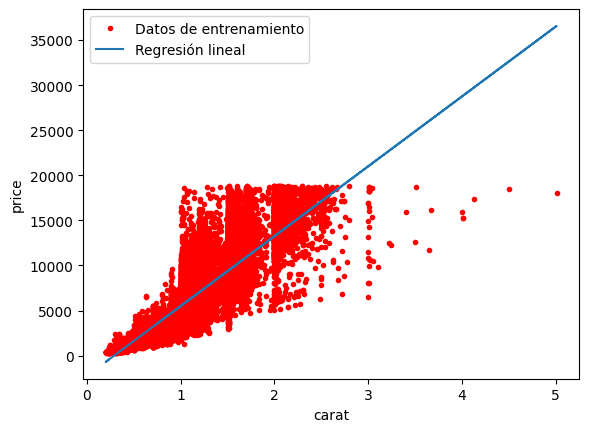

In [19]:
# grafica la linea de ajuste
plotData(X[:, 1], y)

pyplot.plot(X[:, 1], np.dot(X, theta), '-')

pyplot.legend(['Datos de entrenamiento', 'Regresión lineal'])

pyplot.show()

In [20]:
# Predicción del precio de diamantes según su peso (carat)

predict1 = np.dot([1, 0.5], theta)
print('Para un diamante de 0.5 carat, el precio predicho es {:.2f}'.format(predict1))

predict2 = np.dot([1, 1.0], theta)
print('Para un diamante de 1.0 carat, el precio predicho es {:.2f}'.format(predict2))

Para un diamante de 0.5 carat, el precio predicho es 1625.23
Para un diamante de 1.0 carat, el precio predicho es 5499.39


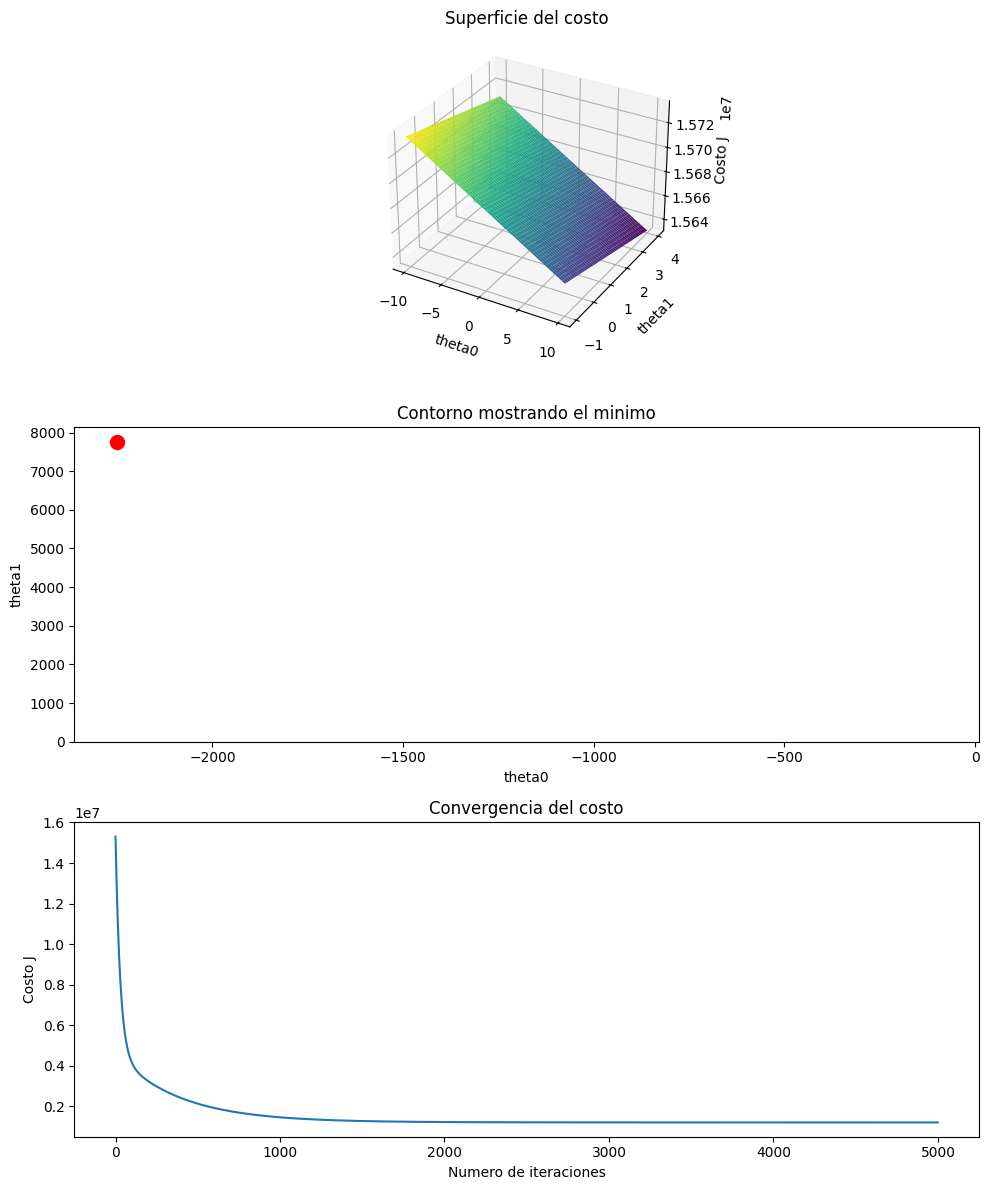

In [21]:
# cuadrícula sobre la que se calcula J
theta0_vals = np.linspace(-10, 10, 50)
theta1_vals = np.linspace(-1, 4, 50)

# inicializa J_vals
J_vals = np.zeros((len(theta0_vals), len(theta1_vals)))

# calcular valores de costo
for i, theta0 in enumerate(theta0_vals):
    for j, theta1 in enumerate(theta1_vals):
        t = np.array([theta0, theta1])
        J_vals[i, j] = calcularCosto(X, y, t)

# transponer matriz
J_vals = J_vals.T


# =========================
# GRAFICA 1 SUPERFICIE 3D
# =========================

fig = pyplot.figure(figsize=(10,12))

ax = fig.add_subplot(311, projection='3d')

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

ax.plot_surface(T0, T1, J_vals, cmap='viridis')

ax.set_xlabel('theta0')
ax.set_ylabel('theta1')
ax.set_zlabel('Costo J')
ax.set_title('Superficie del costo')


# =========================
# GRAFICA 2 CONTORNO
# =========================

ax = pyplot.subplot(312)

pyplot.contour(theta0_vals, theta1_vals, J_vals,
               levels=np.logspace(-2,3,20),
               cmap='viridis')

pyplot.xlabel('theta0')
pyplot.ylabel('theta1')

pyplot.plot(theta[0], theta[1], 'ro', ms=10)

pyplot.title('Contorno mostrando el minimo')


# =========================
# GRAFICA 3 CONVERGENCIA
# =========================

ax = pyplot.subplot(313)

pyplot.plot(np.arange(len(J_history)), J_history)

pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

pyplot.title('Convergencia del costo')

pyplot.tight_layout()